<a href="https://colab.research.google.com/github/2anoFIAP/cp4nemec/blob/main/CP4Nemec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#Joao Vitor Parizotto rocha RM: 562719
#Guilherme de Araujo Moreira RM: 561848

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('checkpoint_magos_dados.csv')

df_duelo = df[df['contexto'] == 'duelo_real']

grupo_a = df_duelo[df_duelo['mago'] == 'Albus Dumbledore']['controle_pct']
grupo_b = df_duelo[df_duelo['mago'] != 'Albus Dumbledore']['controle_pct']

stat_shap, p_shap = stats.shapiro(df_duelo['controle_pct'])
print(f"Teste de Shapiro-Wilk p-valor: {p_shap:.4f}")

stat_lev, p_lev = stats.levene(grupo_a, grupo_b)
print(f"Teste de Levene p-valor: {p_lev:.4f}")

stat_t, p_t = stats.ttest_ind(grupo_a, grupo_b, equal_var=False, alternative='greater')
print(f"Teste de Welch p-valor: {p_t:.6f}")

print("-" * 70)

alpha = 0.05
if p_t < alpha:
    print(f"Como p ({p_t:.6f}) < alpha ({alpha}), REJEITAMOS H0!")
    print("Conclusão: Dumbledore é estatisticamente mais habilidoso em controle no duelo real doq os outros magos.")
else:
    print(f"Como p ({p_t:.6f}) >= alpha ({alpha}), NÃO REJEITAMOS H0.")
    print("Conclusão: Não há evidências suficientes de que Dumbledore seja melhor.")


Teste de Shapiro-Wilk p-valor: 0.4959
Teste de Levene p-valor: 0.0398
Teste de Welch p-valor: 0.000069
----------------------------------------------------------------------
Como p (0.000069) < alpha (0.05), REJEITAMOS H0!
Conclusão: Dumbledore é estatisticamente mais habilidoso em controle no duelo real doq os outros magos.


/tmp/ipykernel_7331/1702831115.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_duelo, x='Grupo', y='controle_pct',


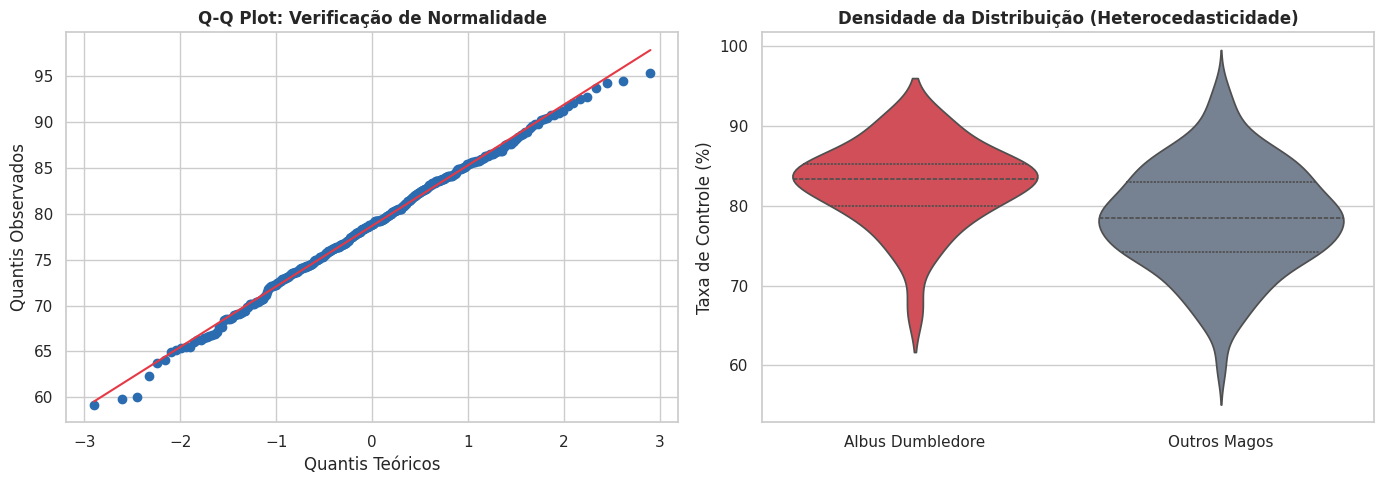

In [16]:
df_duelo = df_duelo.copy()
df_duelo['Grupo'] = df_duelo['mago'].apply(lambda x: 'Albus Dumbledore' if x == 'Albus Dumbledore' else 'Outros Magos')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Q-Q Plot
stats.probplot(df_duelo['controle_pct'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Verificação de Normalidade', fontweight='bold')
axes[0].set_ylabel('Quantis Observados')
axes[0].set_xlabel('Quantis Teóricos')

axes[0].get_lines()[0].set_markerfacecolor('#2b6cb0')
axes[0].get_lines()[0].set_markeredgecolor('#2b6cb0')
axes[0].get_lines()[1].set_color('#e63946')

# Gráfico 2: Gráfico de Violino
sns.violinplot(data=df_duelo, x='Grupo', y='controle_pct',
               palette={'Albus Dumbledore': '#e63946', 'Outros Magos': '#718096'},
               inner="quartile", ax=axes[1])
axes[1].set_title('Densidade da Distribuição (Heterocedasticidade)', fontweight='bold')
axes[1].set_ylabel('Taxa de Controle (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()